# From a chosen design to files and instruments

The previous notebook ended with a promoter combination that measured best in a
library of 512. This one turns that answer into the things a build actually
consumes: a sequence that a vendor will synthesise, a plasmid map you can hand to
a colleague, a pick list an acoustic dispenser will load, a protocol a liquid
handler will run, and a thermocycler program.

Two habits run through it.

**Order matters, and it is not the order the tools are listed in.** The vector is
chosen *first*, because it fixes the assembly enzyme, the sites the insert must
avoid, and the reading frame the CDS must join. Choosing it last — after the
insert is already designed — is how an insert with two internal NdeI sites ends
up destined for an NdeI cloning site.

**Every artefact is checked against something outside itself.** The GenBank file
is read back and compared to what was written. The Opentrons protocol is not
merely generated but *simulated*. A pick list that would draw more liquid than a
source well holds is refused rather than emitted.

In [1]:
import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — The design we are building

Carry over the winner from the DBTL notebook. `sequences=True` joins the real
150-nt sequence measured for each variant, so what gets built below is the DNA
that was actually assayed rather than a reconstruction of it.

In [2]:
library = ov.synbio.fetch_promoter_library(sequences=True)
winner = library.nlargest(1, 'log2_expression').iloc[0]
promoter = winner['sequence']
print(f"{winner['minus35']} / {winner['spacer']} / {winner['minus10']}")
print(f"log2 expression {winner['log2_expression']:.3f}, measured over {winner['n_barcodes']} barcodes")

consensus35 / P1-6-17bp / 12T->A
log2 expression 5.128, measured over 11 barcodes


In [3]:
print('promoter fragment:', len(promoter), 'nt')
print('GC content:', round(ov.synbio.gc_content(promoter), 3))
print(promoter[:60] + ' ...')

promoter fragment: 150 nt
GC content: 0.447
GCGGCGTAAACGCCTTATCCGGCCTACGGAGGGTGCGGGAATTTGTAGGCCTGATAAGAC ...


## 2 — The vector, first

`select_backbone` scores a catalogue against what the construct needs. It is a
catalogue lookup, not a sequence-level check — which is exactly why the sites it
implies have to be checked separately in the next section.

In [4]:
choices = ov.synbio.select_backbone(host='e_coli', insert_kb=1.2, expression=True)
for choice in choices[:3]:
    print(f"{choice.backbone.name:14s} {choice.score:5.2f}  {choice.backbone.marker:10s} {choice.reasons[:2]}")

pCDF-1b         2.40  streptomycin ['带表达启动子 T7']
pET22b          2.40  ampicillin ['带表达启动子 T7']
pET28a          2.40  kanamycin  ['带表达启动子 T7']


In [5]:
vector = choices[0].backbone
print(vector.name, '| origin', vector.origin, '| copy number', vector.copy_number)
print('max insert', vector.max_insert_kb, 'kb | promoter', vector.promoter)

pCDF-1b | origin CloDF13 | copy number low
max insert 6.0 kb | promoter T7


## 3 — The insert, designed against that vector

The gene is codon-optimised **with the vector's cloning enzymes excluded**. Doing
this after the fact is not possible: the optimiser cannot remove a site from a
sequence it has already returned, and a site inside the CDS cannot be edited
without changing codons.

In [6]:
protein = ov.synbio.reference_protein('gfp')
forbidden = ['NdeI', 'XhoI', 'BsaI', 'BsmBI', 'BbsI']
optimised = ov.synbio.codon_optimize(protein, host='e_coli', avoid_enzymes=forbidden)
print(optimised)
print('CAI in E. coli:', round(ov.synbio.cai(optimised.sequence), 3))

CodonResult(host='e_coli', len=714, edits=177, GC=0.49, constraints_ok=True)
CAI in E. coli: 0.985


In [7]:
cds = optimised.sequence + 'TAA'
print('stop codon appended ->', len(cds), 'nt =', len(cds) // 3, 'codons')
print('sites that would break cloning:', ov.synbio.restriction_map(cds, enzymes=forbidden))

stop codon appended -> 717 nt = 239 codons
sites that would break cloning: {'NdeI': [231, 651], 'BbsI': [522]}


A stop codon is not optional and `codon_optimize` does not add one: it
reverse-translates the protein it was given. Without it the ribosome reads through
into whatever follows.

The terminator gets checked rather than assumed.

In [8]:
terminator = ov.synbio.RRNB_T1
strength = ov.synbio.terminator_strength(terminator)
print(strength)

TerminatorResult(strong, strength=0.92, stem=7, U-tract=6)


## 4 — Will a vendor make it?

`synthesis_complexity` looks for what actually gets orders rejected. Run it on the
sequence being ordered, not on a demonstration string.

In [9]:
# the RBS travels with the promoter fragment — it has to be *in* a fragment,
# not merely in a variable, or the assembled construct cannot be translated
promoter_rbs = promoter + 'AAAGGAGGAGATATACAT'
fragments_to_build = [promoter_rbs, cds, terminator]
complexity = ov.synbio.synthesis_complexity("".join(fragments_to_build))
print(complexity)

SynthesisAssessment(routine, score=0.22, 12 issues, GC=47.7%)


In [10]:
for issue in complexity.issues[:5]:
    print(' -', issue)
print('GC over the whole insert:', round(complexity.gc_content, 3))

 - gc_extreme(51-100: GC=30% in a 50-nt window)
 - gc_extreme(326-375: GC=66% in a 50-nt window)
 - gc_extreme(576-625: GC=34% in a 50-nt window)
 - homopolymer(67-74: 8xT)
 - homopolymer(461-468: 8xT)
GC over the whole insert: 0.477


## 5 — Assembly, two ways

Golden Gate needs orthogonal 4-nt junctions; Gibson needs homology arms. Both are
offered because the choice is driven by the vector and the fragment count, not by
preference.

In [11]:
overhangs = ov.synbio.design_overhang_set(3)
fidelity = ov.synbio.overhang_fidelity(overhangs)
print('junctions:', overhangs)
print(fidelity)

junctions: ['ACTG', 'CGAT', 'GTCA']
FidelityReport(3 overhangs, fidelity=1.000 [mismatch], high fidelity)


In [12]:
ready = ov.synbio.domesticate(fragments_to_build, overhangs=overhangs)
golden = ov.synbio.golden_gate(ready)
print('domesticated lengths:', [len(f) for f in ready])
print('golden gate ->', len(golden.sequence), 'bp,', 'circular' if golden.circular else 'linear')

domesticated lengths: [190, 739, 54]
golden gate -> 929 bp, circular


In [13]:
armed = ov.synbio.gibson_arms(fragments_to_build, overlap=25)
gibson = ov.synbio.gibson_assembly(armed, min_overlap=20)
print('with homology arms:', [len(f) for f in armed])
print('gibson ->', len(gibson.sequence), 'bp')

with homology arms: [193, 742, 57]
gibson -> 917 bp


`golden_gate` refuses raw fragments, and it is right to: a Golden Gate fragment
has to carry the Type IIS site and its junction overhang at each end.
`domesticate` adds them, and `gibson_arms` does the corresponding job for Gibson —
appending each fragment's downstream neighbour's first 25 bases, which is exactly
the 5' tail you order on the amplification primer. Both functions refuse work they
cannot do correctly: `domesticate` rejects a fragment that already contains the
enzyme's site internally — the enzyme would cut the fragment in half, and that
cannot be repaired at this stage. It has to be removed upstream, which for a
coding sequence means the `avoid_enzymes=` in §3.

In [14]:
try:
    ov.synbio.domesticate(['GGTCTCAAAATGAAACGC'], overhangs=['AATG'])
except ValueError as exc:
    print(str(exc)[:150])

第 1 个片段内部第 0 位含 BsaI 位点(正向) —— 酶会把片段切开。这一步无法修正:编码序列请用 codon_optimize(..., avoid_enzymes=['BsaI']) 重新生成,非编码片段请换一个酶或改序列。


## 6 — The construct as a file

This is the deliverable a colleague or a vendor actually receives, and it is the
step most often skipped: a sequence in a variable is not a plasmid map.
`annotate_construct` scans for ORFs and a motif library, and the file is then
**read back and compared** — a round trip is the only way to know the writer and
the reader agree.

It is worth knowing what that annotation does and does not find. ORFs above the
length cutoff and the motifs in its table, on both strands; **not** the sigma70
boxes of the promoter, which `promoter_strength` can score but which are not in the
motif table. A map with the CDS and the RBS on it is useful; it is not a curated
plasmid map, and the features it does not draw are still there.

In [15]:
features = ov.synbio.annotate_construct(golden.sequence)
for feature in features[:6]:
    print(f"  {feature['type']:14s} {feature['strand']} {feature['start']:5d}-{feature['end']:<5d} {feature['name']}")

  CDS            -   110-869   ORF_252aa
  RBS            +   156-162   Shine_Dalgarno
  CDS            +   176-893   ORF_238aa


In [16]:
genbank_path = 'gfp_expression_construct.gb'
ov.synbio.write_genbank(golden.sequence, features, path=genbank_path, name='pGFP_win', circular=True)
reloaded, reloaded_features = ov.synbio.read_genbank(genbank_path)
print('round trip identical:', reloaded.upper() == golden.sequence.upper())
print(f'{len(reloaded_features)} features survived the round trip')

round trip identical: True
3 features survived the round trip


In [17]:
sbol_path = 'gfp_expression_construct.xml'
ov.synbio.write_sbol(golden.sequence, features, name='pGFP_win', path=sbol_path)
sbol_sequence, sbol_features = ov.synbio.read_sbol(sbol_path)
print('SBOL round trip identical:', sbol_sequence.upper() == golden.sequence.upper())
print(f'{len(sbol_features)} features in the SBOL document')

SBOL round trip identical: True
3 features in the SBOL document


GenBank is what a vendor and a colleague read; SBOL is what another tool reads.
Writing both costs two lines and removes the step where someone retypes a
sequence.

## 7 — The plate

Everything downstream consumes a plate, so the layout comes first — and the
layout is where the statistics are won or lost. Replicates are spread rather than
placed side by side, the perimeter is reserved because it evaporates fastest, and
positions are randomised so that plate position is not collinear with the design.

In [18]:
constructs = [f'win{i + 1}' for i in range(6)]
plate = ov.synbio.plate_layout(constructs, plate='96', controls=['blank', 'empty_vector'],
                               replicates=3, randomise=True, avoid_edges=True, seed=7,
                               name='assemblies')
print(plate)
print('win1 replicates at:', [w for w, item in plate.contents.items() if item.startswith('win1')])

Plate('assemblies', 96-well, 20/96 used)
win1 replicates at: ['C4', 'B3', 'B7']


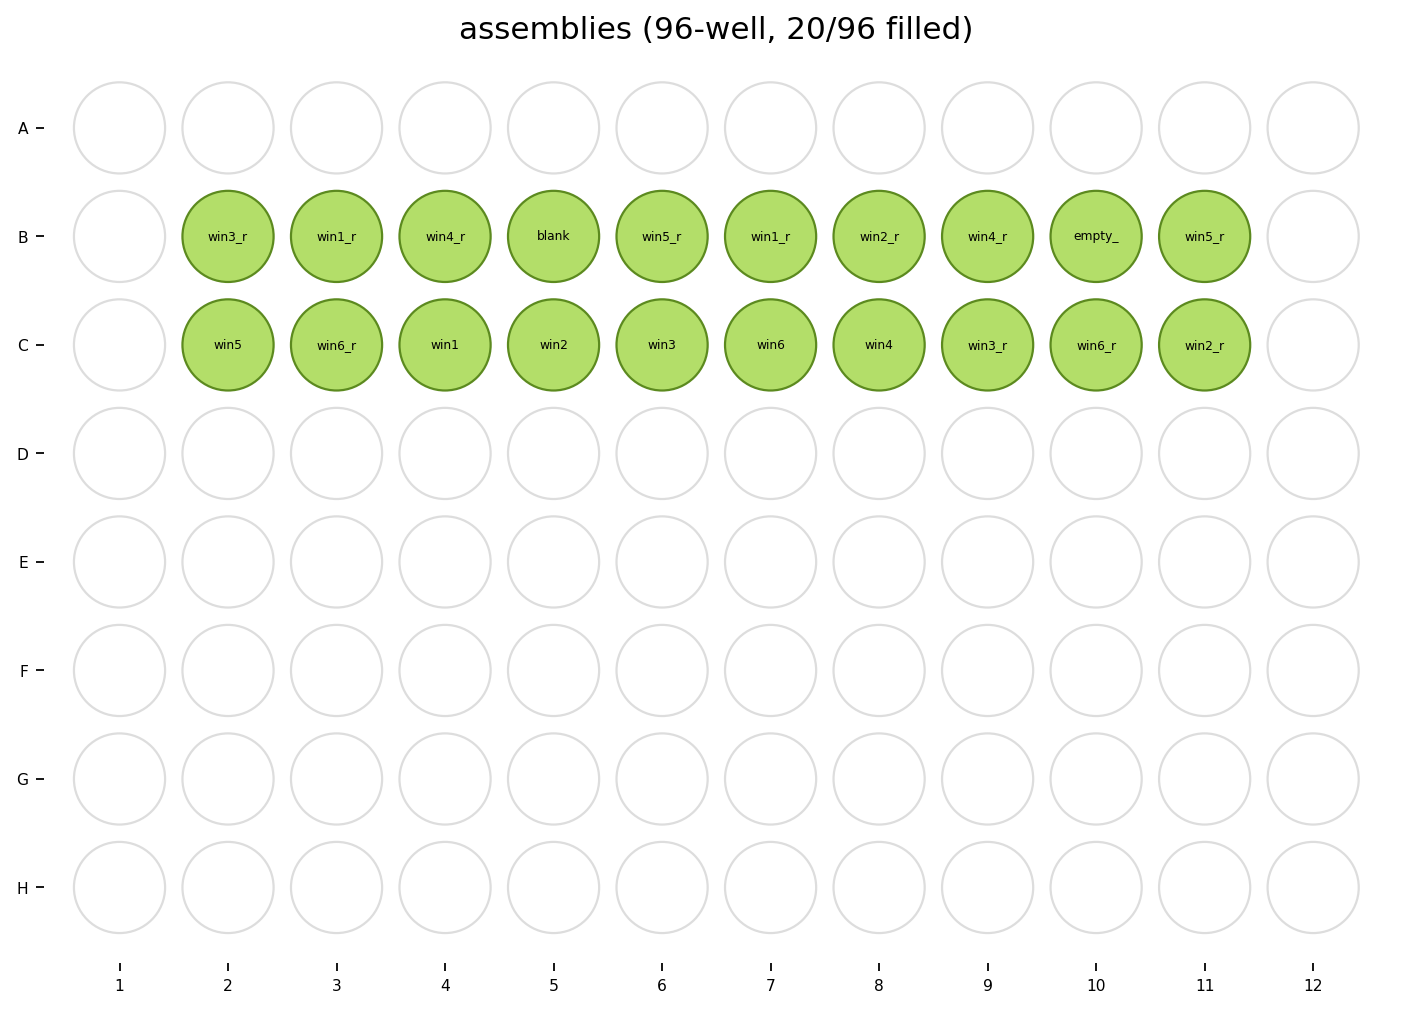

In [19]:
ov.synbio.plot_plate(plate, highlight=[plate.well_of('blank')])
None

## 8 — Volumes

Equal volumes of fragments at equal ng/µL are **not** equimolar once the fragments
differ in length. This is the calculation done by hand before every assembly and
the one most often done wrong.

In [20]:
fragments = {'vector': (3400, 62.0), 'promoter': (len(promoter), 18.0), 'insert': (len(cds), 41.0)}
for name, (length, conc) in fragments.items():
    print(f'  {name:10s} {length:5d} bp at {conc:5.1f} ng/µL = {ov.synbio.dna_nm(conc, length):6.2f} nM')

  vector      3400 bp at  62.0 ng/µL =  28.05 nM
  promoter     150 bp at  18.0 ng/µL = 184.62 nM
  insert       717 bp at  41.0 ng/µL =  87.97 nM


In [21]:
source = ov.synbio.plate_layout(list(fragments), name='fragments',
                                volumes_ul={name: 25.0 for name in fragments})
worklist = ov.synbio.assembly_worklist(fragments, method='golden_gate', final_volume_ul=20.0,
                                       construct='win1')
print(worklist)
print(worklist.to_frame().to_string(index=False))

Worklist(golden_gate, 5 transfers, 20.0 µL total)
                  item source_plate source_well dest_plate dest_well  volume_ul
                vector    fragments              reactions        A1      0.713
              promoter    fragments              reactions        A1      0.217
                insert    fragments              reactions        A1      0.455
golden_gate_master_mix     reagents              reactions        A1     10.000
                 water     reagents              reactions        A1      8.615


## 9 — The acoustic dispenser

Volumes come out in nanolitres snapped to the instrument's droplet resolution,
and the master mix is deliberately **not** in the file: a glycerol-containing
enzyme mix falls outside every calibrated Echo fluid class, so in practice the DNA
is dispensed acoustically and the reagents go on tips.

In [22]:
picklist = ov.synbio.echo_picklist(worklist, source_plate=source, dest_plate=plate)
print(picklist)

Source Plate Name,Source Plate Type,Source Well,Destination Plate Name,Destination Well,Transfer Volume,Sample Name
fragments,384PP_AQ_BP,A1,reactions,C4,712.5,vector
fragments,384PP_AQ_BP,A2,reactions,C4,217.5,promoter
fragments,384PP_AQ_BP,A3,reactions,C4,455.0,insert



The destination well is `win1`'s well from the plate map — not `A1`, which holds
the blank.

A pick list that cannot be executed is refused rather than emitted. Ask for the
same transfers out of a nearly-empty source plate:

In [23]:
nearly_empty = ov.synbio.plate_layout(list(fragments), name='fragments',
                                      volumes_ul={'vector': 2.6, 'promoter': 25.0, 'insert': 25.0})
try:
    ov.synbio.echo_picklist(worklist, source_plate=nearly_empty, dead_volume_ul=2.5)
except ValueError as exc:
    print(str(exc)[:220])

源板体积不够,这份 pick list 跑不完:A1 需要 0.71 µL,可用 0.10 µL(装载 2.60 − 死体积 2.50)。提高 plate_layout(volumes_ul=...) 里的装载体积,或降低 backbone_fmol/final_volume_ul。


## 10 — The liquid handler

The same transfers as a runnable Opentrons Protocol API v2 script. Reagents are
added before DNA, because a sub-microlitre DNA transfer dispensed into a dry well
stays on the wall.

In [24]:
protocol = ov.synbio.opentrons_protocol(worklist, source_plate=source, dest_plate=plate,
                                        pipette='p20_single_gen2', out='assemble_win1.py')
print(protocol[protocol.index('def run'):][:900])

def run(protocol: protocol_api.ProtocolContext) -> None:
    source = protocol.load_labware("biorad_96_wellplate_200ul_pcr", 1)
    dest = protocol.load_labware("biorad_96_wellplate_200ul_pcr", 2)
    tips = protocol.load_labware("opentrons_96_tiprack_20ul", 3)
    reagents = protocol.load_labware("nest_12_reservoir_15ml", 4)
    pipette = protocol.load_instrument("p20_single_gen2", "right", tip_racks=[tips])

    protocol.comment("WARNING vector: 0.713 µL is below the p20_single_gen2 minimum (1.0 µL) — dilute the stock")
    protocol.comment("WARNING promoter: 0.217 µL is below the p20_single_gen2 minimum (1.0 µL) — dilute the stock")
    protocol.comment("WARNING insert: 0.455 µL is below the p20_single_gen2 minimum (1.0 µL) — dilute the stock")
    pipette.transfer(8.615, reagents["A1"], dest["C4"], new_tip="always")   # water
    pipette.transfer(10.0, reagents["A2"], dest["C4"], new


Warnings are emitted as `protocol.comment()` rather than Python comments, so they
reach the run log and the Opentrons app instead of only the file. Anything below
the pipette's minimum volume is flagged there.

**This script can be checked without a robot.** `opentrons_simulate
assemble_win1.py` replays it against the deck model and reports every aspirate
and dispense; a protocol that loads labware into an occupied slot, or asks a
pipette for a volume outside its range, fails there rather than at the bench.

## 11 — The thermocycler

Derived from the primers' melting temperatures and the amplicon length, not from
a default someone forgot to change.

In [25]:
primers = ov.synbio.design_primers(cds, product_size_range=(len(cds) - 80, len(cds)))
pair = primers[0]
print(pair)
print(f'covers {100 * pair.product_size / len(cds):.0f}% of the {len(cds)} nt CDS')

PrimerPair(product=637bp, Tm=60.0/60.1, L=TTCTGGTGGAACTGGATGGC, R=GCGGTCACAAATTCCAGCAG)
covers 89% of the 717 nt CDS


In [26]:
program = ov.synbio.pcr_protocol(tm_forward=pair.left_tm, tm_reverse=pair.right_tm,
                                 amplicon_bp=pair.product_size, polymerase='q5')
print(program.to_text())

# q5 — lid 105 C, 30 cycles, 25.5 min total
1x  initial         98.0 C    30.0 s
30x denature        98.0 C    10.0 s
30x anneal          63.0 C    20.0 s
30x extend          72.0 C    15.9 s
1x  final_extension  72.0 C   120.0 s
HOLD             4.0 C  infinite
# annealing = min(Tm) 60.0 °C +3 °C = 63.0 °C (q5 convention)
# extension = 25 s/kb x 0.64 kb = 16 s



The heated-lid setpoint and the 4 °C hold are part of the program, and
`total_minutes` counts the once-only steps once — which is the difference between
a 26-minute run and a 95-minute estimate of it.

## 12 — Parts from a registry

`query_parts` and `fetch_part` reach an external registry, and they refuse to do
so unless asked. A library function that quietly opens a network connection is a
problem in a batch job and worse behind an institutional proxy.

In [27]:
try:
    ov.synbio.fetch_part('BBa_J23100')
except ValueError as exc:
    print(str(exc).splitlines()[0])

fetch_part 需要联网,请显式传 allow_network=True。


## What was produced

| artefact | file | checked by |
|---|---|---|
| annotated plasmid | `gfp_expression_construct.gb` | read back, sequence compared |
| machine-readable design | `gfp_expression_construct.xml` | read back, sequence compared |
| acoustic transfer list | printed above | source volume vs dead volume |
| liquid-handler protocol | `assemble_win1.py` | `opentrons_simulate` |
| thermocycler program | printed above | derived from measured Tm |

**What is still on you.** The junctions are designed but not sequence-verified
against the vector's real map — `Backbone` in the catalogue carries a name, an
origin and a marker, not a sequence, so `select_backbone` cannot check site
collisions for you. That is why the insert was designed with the cloning enzymes
excluded up front, and why the restriction map in §3 is a check you should keep
running after every edit to the insert.